In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.linear_model import Ridge,Lasso
from sklearn.ensemble import RandomForestRegressor

In [10]:
df=pd.read_csv("house_prices.csv")

In [11]:
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [12]:
df.shape

(1460, 81)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [14]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [ ]:
df=df.drop(['PoolQC','MiscFeature','Fence','Alley'],axis=1)

In [21]:
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,...,112,0,0,0,0,4,2010,WD,Normal,142125


In [23]:
df.fillna(df.median(numeric_only=True),inplace=True)

In [28]:
df.fillna("None",inplace=True)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 77 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [32]:
df.isnull().sum().sum()

np.int64(0)

In [37]:
df["SalePrice"]=np.log(df["SalePrice"])

In [42]:
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,12.247694
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,12.109011
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,12.317167
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,272,0,0,0,0,2,2006,WD,Abnorml,11.849398
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,12.429216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,8,2007,WD,Normal,12.072541
1456,1457,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2010,WD,Normal,12.254863
1457,1458,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,2500,5,2010,WD,Normal,12.493130
1458,1459,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,...,112,0,0,0,0,4,2010,WD,Normal,11.864462


In [39]:
df.duplicated().sum()

np.int64(0)

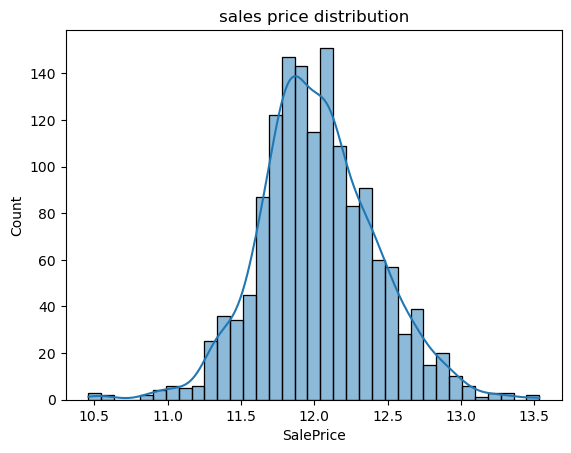

In [41]:
#SalesPrice Distribution
sns.histplot(df['SalePrice'],kde=True)
plt.title("sales price distribution")
plt.show()

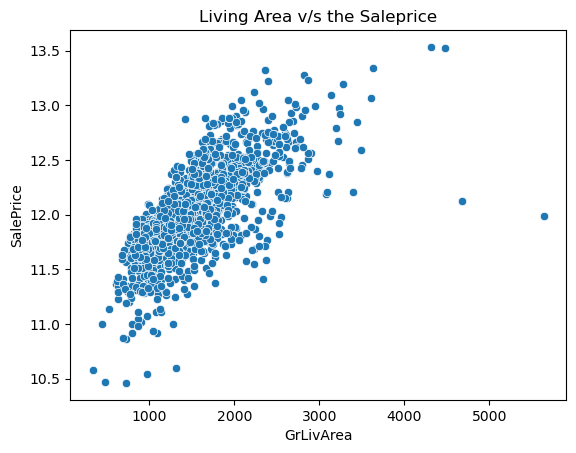

In [43]:
#Living Area v/s Salesprice
sns.scatterplot(x=df["GrLivArea"],y=df['SalePrice'])
plt.title("Living Area v/s the Saleprice")
plt.show()

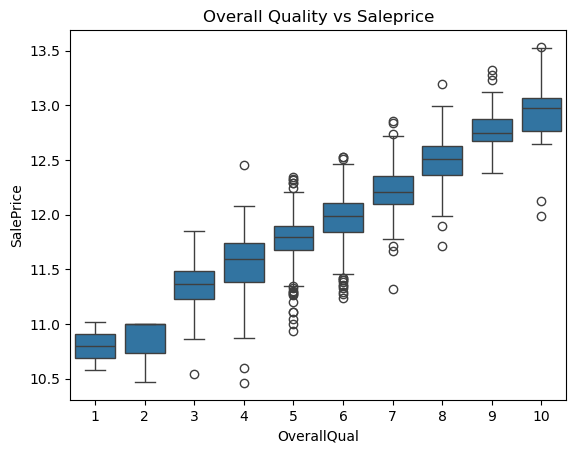

In [44]:
#Quality v/s Salesprice
sns.boxplot(x=df['OverallQual'],y=df["SalePrice"])
plt.title("Overall Quality vs Saleprice")
plt.show()

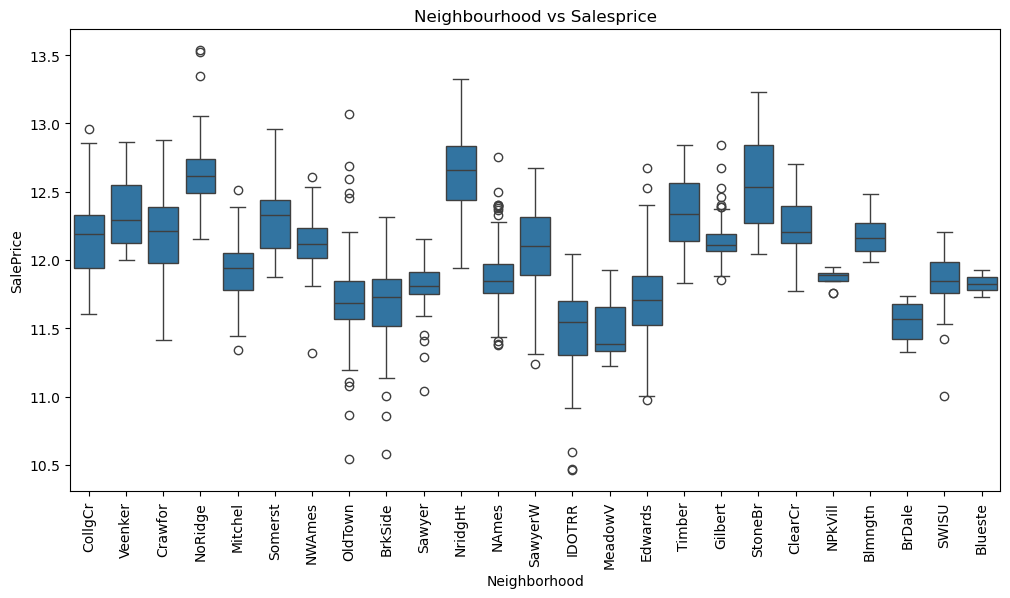

In [48]:
#Neighbourhood v/s Salesprice
plt.figure(figsize=(12,6))
sns.boxplot(x=df['Neighborhood'],y=df['SalePrice'])
plt.xticks(rotation=90)
plt.title("Neighbourhood vs Salesprice")
plt.show()

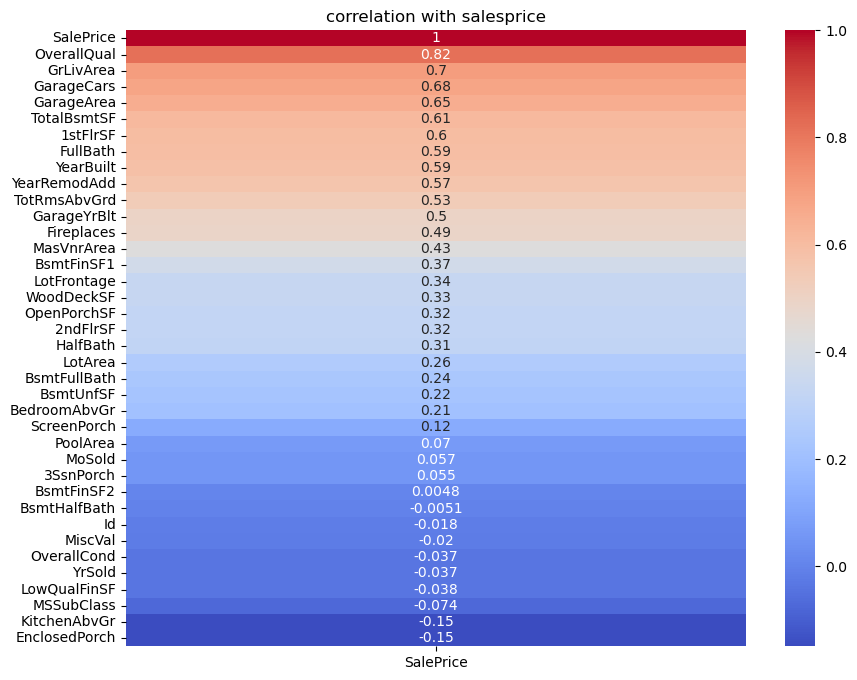

In [50]:
#Finding the correlation of salesprice with other numerical columns
plt.figure(figsize=(10,8))
corr=df.corr(numeric_only=True)
sale_corr=corr['SalePrice'].sort_values(ascending=False)
sns.heatmap(sale_corr.to_frame(),annot=True,cmap='coolwarm')
plt.title("correlation with salesprice")
plt.show()

In [51]:
#create new features from existing features
df["HouseAge"]=2026-df['YearBuilt']

In [52]:
df['TotalArea']=df['TotalBsmtSF']+df['1stFlrSF']+df['2ndFlrSF']

In [53]:
df['TotalBath']=(df['FullBath']+df['HalfBath']*0.5+df['BsmtFullBath']+df['BsmtHalfBath']*0.5)

In [54]:
df['GarageScore']=df['GarageCars']+df['GarageArea']

In [55]:
df[['HouseAge','TotalArea','TotalBath','GarageScore']].head()

,HouseAge,TotalArea,TotalBath,GarageScore
0,23,2566,3.5,550
1,50,2524,2.5,462
2,25,2706,3.5,610
3,111,2473,2.0,645
4,26,3343,3.5,839


In [56]:
df=pd.get_dummies(df,drop_first=True)

In [60]:
X=df.drop('SalePrice',axis=1)
y=df['SalePrice']

In [62]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [64]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [66]:
#Linear REgression
model=LinearRegression()

In [67]:
model.fit(X_train,y_train)

LinearRegression()

In [69]:
y_pred=model.predict(X_test)

In [81]:
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
r2=r2_score(y_test,y_pred)
print("RMSE",rmse)
print("R2_score",r2_score)

RMSE 0.21083372855383825
R2_score <function r2_score at 0x00000123A64C68E0>


In [73]:
#Ridge
ridge=Ridge()

In [74]:
ridge.fit(X_train,y_train)

Ridge()

In [76]:
y_pred_ridge=ridge.predict(X_test)

In [80]:
print("Ridge RMSE",np.sqrt(mean_squared_error(y_test,y_pred_ridge)))
print("Ridge MAE",mean_absolute_error(y_test,y_pred_ridge))
print("Ridge R2",r2_score(y_test,y_pred_ridge))

Ridge RMSE 0.20098834446124464
Ridge MAE 0.09734980655090969
Ridge R2 0.7835295374710742


In [86]:
#lasso
lasso=Lasso()

In [87]:
lasso.fit(X_train,y_train)

Lasso()

In [88]:
y_pred_lasso=lasso.predict(X_test)

In [89]:
print("Lasso RMSE",np.sqrt(mean_squared_error(y_test,y_pred_lasso)))
print("Lasso MAE",mean_absolute_error(y_test,y_pred_lasso))
print("Lasso R2",r2_score(y_test,y_pred_lasso))

Lasso RMSE 0.43324686081152136
Lasso MAE 0.3371360247419879
Lasso R2 -0.005837327142055315


In [91]:
#Random forest
random_forest=RandomForestRegressor(random_state=42)

In [92]:
random_forest.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [93]:
y_pred_random_forest=random_forest.predict(X_test)

In [94]:
print("Random forest RMSE",np.sqrt(mean_squared_error(y_test,y_pred_random_forest)))
print("Random forest MAE",mean_absolute_error(y_test,y_pred_random_forest))
print("Random forest R2",r2_score(y_test,y_pred_random_forest))

Random forest RMSE 0.1487409608412128
Random forest MAE 0.09868122448197846
Random forest R2 0.881445494197381


In [96]:
#Removing the outliers
Q1=df['GrLivArea'].quantile(0.25)
Q3=df['GrLivArea'].quantile(0.75)

In [97]:
IQR=Q3-Q1

In [98]:
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

In [100]:
df_no_outliers=df[(df['GrLivArea']>=lower_bound)&(df['GrLivArea']<=upper_bound)]

In [101]:
print("Before:",df.shape)
print("After",df_no_outliers.shape)

Before: (1460, 253)
After (1429, 253)


In [102]:
#Redefining X and y
X = df_no_outliers.drop("SalePrice", axis=1)
y = df_no_outliers["SalePrice"]

In [103]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [104]:
lr = LinearRegression()

In [105]:
lr.fit(X_train, y_train)

LinearRegression()

In [106]:
y_pred_lr = lr.predict(X_test)

In [107]:
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_lr))
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))

Linear Regression RMSE: 0.12730710480926494
Linear Regression MAE: 0.08532736024518198
Linear Regression R2: 0.8853873854624693
